# Quantifying Domain Shift: MMD, Wasserstein, and A-Distance

**CIS 7000 — Robust Financial Time-Series Forecasting under Domain Shift**

---

Our baseline notebook showed that models trained on AAPL/GOOG/META/NVDA fail on TSLA — but that only demonstrates the *consequences* of domain shift. This notebook measures the *magnitude* of the shift directly using three distribution-level metrics:

1. **Maximum Mean Discrepancy (MMD)** — kernel-based two-sample test (Gretton et al., 2012)
2. **Wasserstein Distance** — optimal transport cost between distributions (Courty et al.)
3. **Proxy A-Distance** — classifier-based divergence measure (Ben-David et al., 2010; used in DANN)

We compare the 18-dimensional feature distributions of each training stock vs TSLA, and also the pooled training set vs TSLA.


---
## §1. Setup & Installation

In [ ]:
!pip install -q numpy pandas scikit-learn matplotlib scipy seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import wasserstein_distance
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("All imports loaded.")


All imports loaded.


---
## §2. Configuration

In [ ]:
HOLDOUT_STOCK = 'TSLA'
TRAIN_CUTOFF = '2024-01-01'

print(f"Holdout stock: {HOLDOUT_STOCK}")
print(f"Train cutoff:  {TRAIN_CUTOFF}")


Holdout stock: TSLA
Train cutoff:  2024-01-01


---
## §3. Data Loading & Feature Engineering

Same pipeline as the baseline notebook — load OHLCV, align stocks, engineer 18 technical features.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_FOLDER = "/content/drive/MyDrive/DL4TS-Term-Project/"

FILE_NAMES = {
    'AAPL': 'Historical_Data_AAPL.csv',
    'GOOG': 'Historical_Data_GOOG.csv',
    'META': 'Historical_Data_META.csv',
    'NVDA': 'Historical_Data_NVDA.csv',
    'TSLA': 'Historical_Data_TSLA.csv',
}


Mounted at /content/drive


In [ ]:
def load_stock_data(folder, file_names):
    stocks = {}
    for ticker, fname in file_names.items():
        path = folder + fname
        print(f"Loading {ticker} from {path}...")
        df = pd.read_csv(path)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df['Date'] = df['Date'].dt.tz_localize(None)
        df = df.sort_values('Date').reset_index(drop=True)
        stocks[ticker] = df
        print(f"  {ticker}: {len(df)} rows, {df['Date'].min().date()} to {df['Date'].max().date()}")
    return stocks

def align_stocks(stocks_dict):
    start_dates = {t: df['Date'].min() for t, df in stocks_dict.items()}
    common_start = max(start_dates.values())
    print(f"Common start date: {common_start.date()}")
    aligned = {}
    for ticker, df in stocks_dict.items():
        trimmed = df[df['Date'] >= common_start].copy().reset_index(drop=True)
        aligned[ticker] = trimmed
        print(f"  {ticker}: {len(trimmed)} rows")
    return aligned, common_start

raw_stocks = load_stock_data(DRIVE_FOLDER, FILE_NAMES)
stocks, common_start = align_stocks(raw_stocks)


Loading AAPL from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_AAPL.csv...
  AAPL: 11383 rows, 1980-12-12 to 2026-02-11
Loading GOOG from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_GOOG.csv...
  GOOG: 5405 rows, 2004-08-19 to 2026-02-11
Loading META from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_META.csv...
  META: 3453 rows, 2012-05-18 to 2026-02-11
Loading NVDA from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_NVDA.csv...
  NVDA: 6806 rows, 1999-01-22 to 2026-02-11
Loading TSLA from /content/drive/MyDrive/DL4TS-Term-Project/Historical_Data_TSLA.csv...
  TSLA: 3930 rows, 2010-06-29 to 2026-02-11
Common start date: 2012-05-18
  AAPL: 3453 rows
  GOOG: 3453 rows
  META: 3453 rows
  NVDA: 3453 rows
  TSLA: 3453 rows


In [ ]:
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / (avg_loss + 1e-10)
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, signal=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    histogram = macd_line - signal_line
    return macd_line, signal_line, histogram

def compute_bollinger_bands(series, window=20, num_std=2):
    sma = series.rolling(window=window).mean()
    std = series.rolling(window=window).std()
    upper = sma + num_std * std
    lower = sma - num_std * std
    bandwidth = (upper - lower) / (sma + 1e-10)
    pct_b = (series - lower) / (upper - lower + 1e-10)
    return bandwidth, pct_b

def compute_atr(high, low, close, window=14):
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    return true_range.rolling(window=window).mean()

def compute_obv(close, volume):
    direction = np.sign(close.diff())
    obv = (volume * direction).cumsum()
    obv_roc = obv.pct_change(periods=5)
    return obv_roc

def add_features(df):
    df = df.copy()
    df['log_return'] = np.log(df['Close'] / df['Close'].shift(1))
    for lag in [1, 2, 3, 5]:
        df[f'return_lag_{lag}'] = df['log_return'].shift(lag)
    df['high_low_range'] = ((df['High'] - df['Low']) / df['Close']).shift(1)
    df['open_close_diff'] = ((df['Close'] - df['Open']) / df['Open']).shift(1)
    df['volume_change'] = df['Volume'].pct_change().shift(1)
    df['volume_ma_ratio'] = (df['Volume'] / df['Volume'].rolling(20).mean()).shift(1)
    df['rsi'] = compute_rsi(df['Close']).shift(1)
    macd_line, macd_signal, macd_hist = compute_macd(df['Close'])
    df['macd'] = (macd_line / df['Close']).shift(1)
    df['macd_signal'] = (macd_signal / df['Close']).shift(1)
    df['macd_hist'] = (macd_hist / df['Close']).shift(1)
    bandwidth, pct_b = compute_bollinger_bands(df['Close'])
    df['bb_width'] = bandwidth.shift(1)
    df['bb_pct_b'] = pct_b.shift(1)
    df['atr'] = (compute_atr(df['High'], df['Low'], df['Close']) / df['Close']).shift(1)
    df['obv_roc'] = compute_obv(df['Close'], df['Volume']).shift(1)
    df['realized_vol_5d'] = (df['log_return'].rolling(5).std() * np.sqrt(252)).shift(1)
    df['realized_vol_20d'] = (df['log_return'].rolling(20).std() * np.sqrt(252)).shift(1)
    df['direction'] = (df['log_return'] > 0).astype(int)
    df = df.dropna().reset_index(drop=True)
    return df

stocks_featured = {}
for ticker, df in stocks.items():
    stocks_featured[ticker] = add_features(df)
    print(f"{ticker}: {len(stocks_featured[ticker])} rows after feature engineering")

FEATURE_COLS = [
    'return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5',
    'high_low_range', 'open_close_diff', 'volume_change', 'volume_ma_ratio',
    'rsi', 'macd', 'macd_signal', 'macd_hist',
    'bb_width', 'bb_pct_b', 'atr', 'obv_roc',
    'realized_vol_5d', 'realized_vol_20d'
]

print(f"\nFeature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}")


AAPL: 3432 rows after feature engineering
GOOG: 3432 rows after feature engineering
META: 3432 rows after feature engineering
NVDA: 3432 rows after feature engineering
TSLA: 3432 rows after feature engineering

Feature columns (18): ['return_lag_1', 'return_lag_2', 'return_lag_3', 'return_lag_5', 'high_low_range', 'open_close_diff', 'volume_change', 'volume_ma_ratio', 'rsi', 'macd', 'macd_signal', 'macd_hist', 'bb_width', 'bb_pct_b', 'atr', 'obv_roc', 'realized_vol_5d', 'realized_vol_20d']


---
## §4. Prepare Feature Matrices

We extract the 18 features for each stock and split by the train cutoff. We'll compare:
- Each individual training stock vs TSLA (pre-2024)
- Pooled training stocks vs TSLA (pre-2024)
- Pooled training stocks (pre-2024) vs TSLA (post-2024) — the actual domain shift in our experiments


In [ ]:
cutoff_date = pd.Timestamp(TRAIN_CUTOFF)

# Extract feature matrices per stock, split by time
stock_features = {}
for ticker, df in stocks_featured.items():
    train = df[df['Date'] < cutoff_date][FEATURE_COLS].values
    test = df[df['Date'] >= cutoff_date][FEATURE_COLS].values
    stock_features[ticker] = {'train': train, 'test': test, 'all': df[FEATURE_COLS].values}
    print(f"{ticker}: train={train.shape}, test={test.shape}")

# Pooled training data (all stocks except TSLA, pre-2024)
train_stocks = [t for t in stocks_featured if t != HOLDOUT_STOCK]
pooled_train = np.vstack([stock_features[t]['train'] for t in train_stocks])
tsla_train = stock_features[HOLDOUT_STOCK]['train']
tsla_test = stock_features[HOLDOUT_STOCK]['test']

print(f"\nPooled training: {pooled_train.shape}")
print(f"TSLA train:      {tsla_train.shape}")
print(f"TSLA test:       {tsla_test.shape}")

# Standardize everything using the pooled training scaler
scaler = StandardScaler()
scaler.fit(pooled_train)

pooled_train_scaled = scaler.transform(pooled_train)
tsla_train_scaled = scaler.transform(tsla_train)
tsla_test_scaled = scaler.transform(tsla_test)

stock_train_scaled = {}
for t in train_stocks:
    stock_train_scaled[t] = scaler.transform(stock_features[t]['train'])

print("\nAll features standardized using pooled training scaler.")


AAPL: train=(2902, 18), test=(530, 18)
GOOG: train=(2902, 18), test=(530, 18)
META: train=(2902, 18), test=(530, 18)
NVDA: train=(2902, 18), test=(530, 18)
TSLA: train=(2902, 18), test=(530, 18)

Pooled training: (11608, 18)
TSLA train:      (2902, 18)
TSLA test:       (530, 18)

All features standardized using pooled training scaler.


---
## §5. Maximum Mean Discrepancy (MMD)

MMD measures the distance between two distributions by comparing their embeddings in a reproducing kernel Hilbert space (RKHS). We use a Gaussian (RBF) kernel. If MMD ≈ 0, the distributions are similar. Larger MMD = greater domain shift.

We use the unbiased estimator from Gretton et al. (2012) and also compute a permutation test p-value to assess statistical significance.


In [ ]:
def compute_mmd_rbf(X, Y, gamma=None):
    """
    Compute unbiased MMD^2 with RBF kernel.
    gamma = 1 / (2 * sigma^2). If None, use median heuristic.
    """
    if gamma is None:
        # Median heuristic for bandwidth selection
        XY = np.vstack([X, Y])
        dists = cdist(XY, XY, 'sqeuclidean')
        median_dist = np.median(dists[dists > 0])
        gamma = 1.0 / (median_dist + 1e-10)

    def rbf_kernel(A, B):
        dists = cdist(A, B, 'sqeuclidean')
        return np.exp(-gamma * dists)

    m, n = len(X), len(Y)
    K_XX = rbf_kernel(X, X)
    K_YY = rbf_kernel(Y, Y)
    K_XY = rbf_kernel(X, Y)

    # Unbiased estimator: zero out diagonals for XX and YY
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)

    mmd2 = (K_XX.sum() / (m * (m - 1)) +
            K_YY.sum() / (n * (n - 1)) -
            2 * K_XY.sum() / (m * n))

    return mmd2


def mmd_permutation_test(X, Y, n_permutations=500):
    """Permutation test for MMD significance."""
    observed_mmd = compute_mmd_rbf(X, Y)
    combined = np.vstack([X, Y])
    m = len(X)
    count = 0

    for _ in range(n_permutations):
        perm = np.random.permutation(len(combined))
        X_perm = combined[perm[:m]]
        Y_perm = combined[perm[m:]]
        perm_mmd = compute_mmd_rbf(X_perm, Y_perm)
        if perm_mmd >= observed_mmd:
            count += 1

    p_value = (count + 1) / (n_permutations + 1)
    return observed_mmd, p_value


print("=" * 65)
print("MMD (RBF kernel, median heuristic) — Each Stock vs TSLA")
print("=" * 65)

# Subsample for computational efficiency
np.random.seed(42)
N_SUB = 800  # subsample size

mmd_results = {}

# Each training stock vs TSLA (both pre-2024, same time period)
for ticker in train_stocks:
    src = stock_train_scaled[ticker]
    tgt = tsla_train_scaled
    # Subsample if needed
    src_sub = src[np.random.choice(len(src), min(N_SUB, len(src)), replace=False)]
    tgt_sub = tgt[np.random.choice(len(tgt), min(N_SUB, len(tgt)), replace=False)]
    mmd_val, p_val = mmd_permutation_test(src_sub, tgt_sub, n_permutations=300)
    mmd_results[f"{ticker} vs TSLA (pre-2024)"] = (mmd_val, p_val)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f"  {ticker:4s} vs TSLA (same period): MMD² = {mmd_val:.6f}  p = {p_val:.4f} {sig}")

# Pooled training vs TSLA pre-2024
src_sub = pooled_train_scaled[np.random.choice(len(pooled_train_scaled), N_SUB, replace=False)]
tgt_sub = tsla_train_scaled[np.random.choice(len(tsla_train_scaled), min(N_SUB, len(tsla_train_scaled)), replace=False)]
mmd_val, p_val = mmd_permutation_test(src_sub, tgt_sub, n_permutations=300)
mmd_results["Pooled vs TSLA (pre-2024)"] = (mmd_val, p_val)
sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
print(f"  {'Pool':4s} vs TSLA (same period): MMD² = {mmd_val:.6f}  p = {p_val:.4f} {sig}")

# Pooled training (pre-2024) vs TSLA test (post-2024) — the actual experimental shift
tgt_sub2 = tsla_test_scaled[np.random.choice(len(tsla_test_scaled), min(N_SUB, len(tsla_test_scaled)), replace=False)]
mmd_val2, p_val2 = mmd_permutation_test(src_sub, tgt_sub2, n_permutations=300)
mmd_results["Pooled vs TSLA (post-2024)"] = (mmd_val2, p_val2)
sig = '***' if p_val2 < 0.001 else '**' if p_val2 < 0.01 else '*' if p_val2 < 0.05 else 'n.s.'
print(f"  {'Pool':4s} vs TSLA (post-2024):   MMD² = {mmd_val2:.6f}  p = {p_val2:.4f} {sig}")

# Control: AAPL vs GOOG (two training stocks, should be small)
src_aapl = stock_train_scaled['AAPL'][np.random.choice(len(stock_train_scaled['AAPL']), N_SUB, replace=False)]
src_goog = stock_train_scaled['GOOG'][np.random.choice(len(stock_train_scaled['GOOG']), N_SUB, replace=False)]
mmd_ctrl, p_ctrl = mmd_permutation_test(src_aapl, src_goog, n_permutations=300)
mmd_results["AAPL vs GOOG (control)"] = (mmd_ctrl, p_ctrl)
sig = '***' if p_ctrl < 0.001 else '**' if p_ctrl < 0.01 else '*' if p_ctrl < 0.05 else 'n.s.'
print(f"\n  Control — AAPL vs GOOG:          MMD² = {mmd_ctrl:.6f}  p = {p_ctrl:.4f} {sig}")


MMD (RBF kernel, median heuristic) — Each Stock vs TSLA
  AAPL vs TSLA (same period): MMD² = 0.179707  p = 0.0033 **
  GOOG vs TSLA (same period): MMD² = 0.191595  p = 0.0033 **
  META vs TSLA (same period): MMD² = 0.082499  p = 0.0033 **
  NVDA vs TSLA (same period): MMD² = 0.036056  p = 0.0033 **
  Pool vs TSLA (same period): MMD² = 0.109024  p = 0.0033 **
  Pool vs TSLA (post-2024):   MMD² = 0.171045  p = 0.0033 **

  Control — AAPL vs GOOG:          MMD² = 0.004176  p = 0.0033 **


---
## §6. Wasserstein Distance (1D Projections)

The Wasserstein distance (earth mover's distance) from optimal transport theory measures the minimum "work" needed to transform one distribution into another. Since computing the exact multivariate Wasserstein is expensive in 18 dimensions, we compute it per-feature (1D marginals) and also on the first two PCA components.


In [ ]:
from sklearn.decomposition import PCA

print("=" * 65)
print("WASSERSTEIN DISTANCE — Per-Feature (1D Marginals)")
print("=" * 65)

# Per-feature Wasserstein between pooled training and TSLA test
wass_per_feature = {}
for i, feat in enumerate(FEATURE_COLS):
    w = wasserstein_distance(pooled_train_scaled[:, i], tsla_test_scaled[:, i])
    wass_per_feature[feat] = w

# Sort by distance
sorted_wass = sorted(wass_per_feature.items(), key=lambda x: x[1], reverse=True)
print("\nPooled Train vs TSLA Test (post-2024) — ranked by shift magnitude:\n")
for feat, w in sorted_wass:
    bar = '█' * int(w * 20)
    print(f"  {feat:20s}: {w:.4f}  {bar}")

print(f"\n  Mean Wasserstein:  {np.mean(list(wass_per_feature.values())):.4f}")
print(f"  Max Wasserstein:   {max(wass_per_feature.values()):.4f}  ({sorted_wass[0][0]})")

# Also compute per-stock vs TSLA
print("\n" + "=" * 65)
print("WASSERSTEIN DISTANCE — Mean Across Features, by Source Stock")
print("=" * 65 + "\n")

wass_by_stock = {}
for ticker in train_stocks:
    per_feat = []
    for i in range(len(FEATURE_COLS)):
        w = wasserstein_distance(stock_train_scaled[ticker][:, i], tsla_test_scaled[:, i])
        per_feat.append(w)
    wass_by_stock[ticker] = np.mean(per_feat)
    print(f"  {ticker} vs TSLA: mean W = {wass_by_stock[ticker]:.4f}")

# Control
ctrl_feats = []
for i in range(len(FEATURE_COLS)):
    w = wasserstein_distance(stock_train_scaled['AAPL'][:, i], stock_train_scaled['GOOG'][:, i])
    ctrl_feats.append(w)
wass_by_stock['AAPL vs GOOG'] = np.mean(ctrl_feats)
print(f"\n  Control (AAPL vs GOOG): mean W = {np.mean(ctrl_feats):.4f}")


WASSERSTEIN DISTANCE — Per-Feature (1D Marginals)

Pooled Train vs TSLA Test (post-2024) — ranked by shift magnitude:

  atr                 : 1.8164  ████████████████████████████████████
  realized_vol_20d    : 1.6101  ████████████████████████████████
  bb_width            : 1.3365  ██████████████████████████
  high_low_range      : 1.3268  ██████████████████████████
  realized_vol_5d     : 1.2256  ████████████████████████
  macd_hist           : 0.6932  █████████████
  return_lag_3        : 0.6085  ████████████
  return_lag_2        : 0.6085  ████████████
  return_lag_1        : 0.6074  ████████████
  return_lag_5        : 0.6055  ████████████
  open_close_diff     : 0.5796  ███████████
  macd                : 0.5684  ███████████
  macd_signal         : 0.5658  ███████████
  rsi                 : 0.2293  ████
  bb_pct_b            : 0.2052  ████
  volume_ma_ratio     : 0.1484  ██
  volume_change       : 0.1232  ██
  obv_roc             : 0.0768  █

  Mean Wasserstein:  0.7186
  Max W

---
## §7. Proxy A-Distance

The A-distance measures domain divergence using a classifier: if a linear model can easily distinguish source from target samples, the domains are very different. Defined as:

$$d_A = 2(1 - 2\epsilon)$$

where ε is the classification error. If ε = 0.5 (can't tell them apart), d_A = 0 (no shift). If ε = 0 (perfect separation), d_A = 2 (maximum shift). This is the metric used in Ben-David's theory and the DANN paper.


In [ ]:
def compute_proxy_a_distance(X_source, X_target, n_cv=5):
    """
    Proxy A-distance using logistic regression.
    Label source as 0, target as 1, train a classifier, compute error.
    """
    X = np.vstack([X_source, X_target])
    y = np.concatenate([np.zeros(len(X_source)), np.ones(len(X_target))])

    # Shuffle
    perm = np.random.permutation(len(X))
    X, y = X[perm], y[perm]

    clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs')
    scores = cross_val_score(clf, X, y, cv=n_cv, scoring='accuracy')
    acc = scores.mean()
    error = 1 - acc

    # d_A = 2(1 - 2*error) = 2(2*acc - 1)
    d_a = 2 * (2 * acc - 1)
    d_a = max(0, d_a)  # clip to [0, 2]

    return d_a, acc, error


np.random.seed(42)

print("=" * 65)
print("PROXY A-DISTANCE (Logistic Regression, 5-fold CV)")
print("=" * 65)
print("\nd_A = 0: domains indistinguishable  |  d_A = 2: perfectly separable\n")

a_dist_results = {}

# Each stock vs TSLA
for ticker in train_stocks:
    src = stock_train_scaled[ticker]
    tgt = tsla_train_scaled
    # Balance sample sizes
    n = min(len(src), len(tgt))
    src_sub = src[np.random.choice(len(src), n, replace=False)]
    tgt_sub = tgt[np.random.choice(len(tgt), n, replace=False)]
    d_a, acc, err = compute_proxy_a_distance(src_sub, tgt_sub)
    a_dist_results[f"{ticker} vs TSLA"] = (d_a, acc)
    print(f"  {ticker:4s} vs TSLA (pre-2024): d_A = {d_a:.4f}  (clf acc = {acc:.1%})")

# Pooled vs TSLA pre-2024
n = min(len(pooled_train_scaled), len(tsla_train_scaled))
src_sub = pooled_train_scaled[np.random.choice(len(pooled_train_scaled), n, replace=False)]
tgt_sub = tsla_train_scaled[np.random.choice(len(tsla_train_scaled), n, replace=False)]
d_a, acc, err = compute_proxy_a_distance(src_sub, tgt_sub)
a_dist_results["Pooled vs TSLA (pre-2024)"] = (d_a, acc)
print(f"  Pool vs TSLA (pre-2024):  d_A = {d_a:.4f}  (clf acc = {acc:.1%})")

# Pooled vs TSLA post-2024 (actual experimental shift)
n2 = min(len(pooled_train_scaled), len(tsla_test_scaled))
src_sub2 = pooled_train_scaled[np.random.choice(len(pooled_train_scaled), n2, replace=False)]
tgt_sub2 = tsla_test_scaled[np.random.choice(len(tsla_test_scaled), n2, replace=False)]
d_a2, acc2, err2 = compute_proxy_a_distance(src_sub2, tgt_sub2)
a_dist_results["Pooled vs TSLA (post-2024)"] = (d_a2, acc2)
print(f"  Pool vs TSLA (post-2024): d_A = {d_a2:.4f}  (clf acc = {acc2:.1%})")

# Control
n_ctrl = min(len(stock_train_scaled['AAPL']), len(stock_train_scaled['GOOG']))
src_ctrl = stock_train_scaled['AAPL'][np.random.choice(len(stock_train_scaled['AAPL']), n_ctrl, replace=False)]
tgt_ctrl = stock_train_scaled['GOOG'][np.random.choice(len(stock_train_scaled['GOOG']), n_ctrl, replace=False)]
d_a_ctrl, acc_ctrl, _ = compute_proxy_a_distance(src_ctrl, tgt_ctrl)
a_dist_results["AAPL vs GOOG (control)"] = (d_a_ctrl, acc_ctrl)
print(f"\n  Control (AAPL vs GOOG):   d_A = {d_a_ctrl:.4f}  (clf acc = {acc_ctrl:.1%})")


PROXY A-DISTANCE (Logistic Regression, 5-fold CV)

d_A = 0: domains indistinguishable  |  d_A = 2: perfectly separable

  AAPL vs TSLA (pre-2024): d_A = 1.5059  (clf acc = 87.6%)
  GOOG vs TSLA (pre-2024): d_A = 1.4866  (clf acc = 87.2%)
  META vs TSLA (pre-2024): d_A = 0.8436  (clf acc = 71.1%)
  NVDA vs TSLA (pre-2024): d_A = 0.6237  (clf acc = 65.6%)
  Pool vs TSLA (pre-2024):  d_A = 1.0482  (clf acc = 76.2%)
  Pool vs TSLA (post-2024): d_A = 1.4000  (clf acc = 85.0%)

  Control (AAPL vs GOOG):   d_A = 0.2350  (clf acc = 55.9%)


---
## §8. Visualization: Domain Shift Dashboard

Consolidated view of all three metrics across all comparisons.


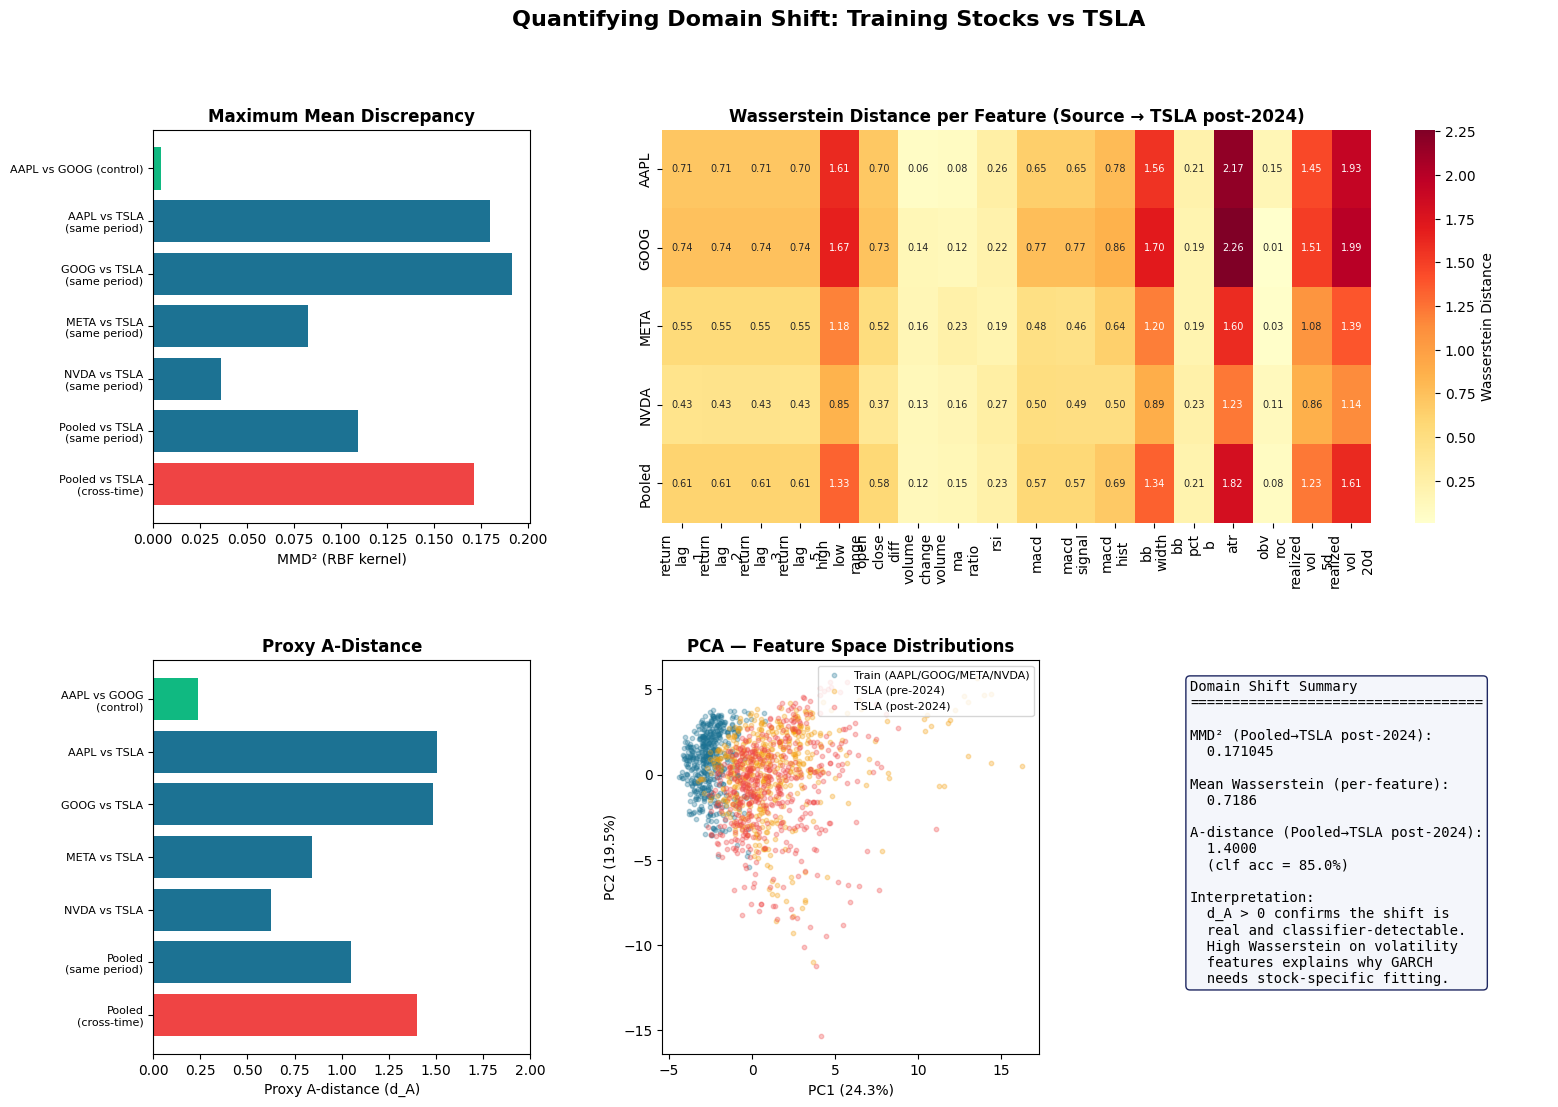

Dashboard saved to domain_shift_dashboard.png


In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Quantifying Domain Shift: Training Stocks vs TSLA", fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(2, 3, hspace=0.35, wspace=0.35)

# --- Plot 1: MMD bar chart ---
ax1 = fig.add_subplot(gs[0, 0])
mmd_labels = []
mmd_vals = []
mmd_colors = []
for key in ["AAPL vs GOOG (control)", "AAPL vs TSLA (pre-2024)", "GOOG vs TSLA (pre-2024)",
            "META vs TSLA (pre-2024)", "NVDA vs TSLA (pre-2024)", "Pooled vs TSLA (pre-2024)",
            "Pooled vs TSLA (post-2024)"]:
    if key in mmd_results:
        label = key.replace(" (pre-2024)", "\n(same period)").replace(" (post-2024)", "\n(cross-time)")
        mmd_labels.append(label)
        mmd_vals.append(mmd_results[key][0])
        if "control" in key:
            mmd_colors.append('#10B981')
        elif "post" in key:
            mmd_colors.append('#EF4444')
        else:
            mmd_colors.append('#1C7293')

ax1.barh(range(len(mmd_labels)), mmd_vals, color=mmd_colors)
ax1.set_yticks(range(len(mmd_labels)))
ax1.set_yticklabels(mmd_labels, fontsize=8)
ax1.set_xlabel("MMD² (RBF kernel)")
ax1.set_title("Maximum Mean Discrepancy", fontweight='bold')
ax1.invert_yaxis()

# --- Plot 2: Wasserstein per-feature heatmap ---
ax2 = fig.add_subplot(gs[0, 1:])
wass_matrix = []
stock_labels_wass = train_stocks + ['Pooled']
for ticker in train_stocks:
    row = []
    for i in range(len(FEATURE_COLS)):
        w = wasserstein_distance(stock_train_scaled[ticker][:, i], tsla_test_scaled[:, i])
        row.append(w)
    wass_matrix.append(row)
# Pooled
pooled_row = []
for i in range(len(FEATURE_COLS)):
    w = wasserstein_distance(pooled_train_scaled[:, i], tsla_test_scaled[:, i])
    pooled_row.append(w)
wass_matrix.append(pooled_row)

wass_df = pd.DataFrame(wass_matrix, index=stock_labels_wass,
                       columns=[f.replace('_', '\n') for f in FEATURE_COLS])
sns.heatmap(wass_df, ax=ax2, cmap='YlOrRd', annot=True, fmt='.2f', annot_kws={'size': 7},
            cbar_kws={'label': 'Wasserstein Distance'})
ax2.set_title("Wasserstein Distance per Feature (Source → TSLA post-2024)", fontweight='bold')
ax2.set_ylabel("")

# --- Plot 3: A-distance bar chart ---
ax3 = fig.add_subplot(gs[1, 0])
a_labels = []
a_vals = []
a_colors = []
for key in ["AAPL vs GOOG (control)", "AAPL vs TSLA", "GOOG vs TSLA",
            "META vs TSLA", "NVDA vs TSLA", "Pooled vs TSLA (pre-2024)",
            "Pooled vs TSLA (post-2024)"]:
    if key in a_dist_results:
        label = key.replace("Pooled vs TSLA (pre-2024)", "Pooled\n(same period)")
        label = label.replace("Pooled vs TSLA (post-2024)", "Pooled\n(cross-time)")
        label = label.replace("AAPL vs GOOG (control)", "AAPL vs GOOG\n(control)")
        a_labels.append(label)
        a_vals.append(a_dist_results[key][0])
        if "control" in key:
            a_colors.append('#10B981')
        elif "post" in key or "cross" in key:
            a_colors.append('#EF4444')
        else:
            a_colors.append('#1C7293')

ax3.barh(range(len(a_labels)), a_vals, color=a_colors)
ax3.set_yticks(range(len(a_labels)))
ax3.set_yticklabels(a_labels, fontsize=8)
ax3.set_xlabel("Proxy A-distance (d_A)")
ax3.set_title("Proxy A-Distance", fontweight='bold')
ax3.set_xlim(0, 2)
ax3.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax3.invert_yaxis()

# --- Plot 4: PCA visualization ---
ax4 = fig.add_subplot(gs[1, 1])
pca = PCA(n_components=2)
all_data = np.vstack([pooled_train_scaled[:500], tsla_train_scaled[:500], tsla_test_scaled[:500]])
pca.fit(all_data)

pool_pca = pca.transform(pooled_train_scaled[:500])
tsla_train_pca = pca.transform(tsla_train_scaled[:500])
tsla_test_pca = pca.transform(tsla_test_scaled[:min(500, len(tsla_test_scaled))])

ax4.scatter(pool_pca[:, 0], pool_pca[:, 1], alpha=0.3, s=10, c='#1C7293', label='Train (AAPL/GOOG/META/NVDA)')
ax4.scatter(tsla_train_pca[:, 0], tsla_train_pca[:, 1], alpha=0.3, s=10, c='#F59E0B', label='TSLA (pre-2024)')
ax4.scatter(tsla_test_pca[:, 0], tsla_test_pca[:, 1], alpha=0.3, s=10, c='#EF4444', label='TSLA (post-2024)')
ax4.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax4.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax4.set_title("PCA — Feature Space Distributions", fontweight='bold')
ax4.legend(fontsize=8, loc='upper right')

# --- Plot 5: Summary comparison ---
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

summary_text = "Domain Shift Summary\n" + "=" * 35 + "\n\n"
summary_text += "MMD² (Pooled→TSLA post-2024):\n"
if "Pooled vs TSLA (post-2024)" in mmd_results:
    summary_text += f"  {mmd_results['Pooled vs TSLA (post-2024)'][0]:.6f}\n\n"
summary_text += "Mean Wasserstein (per-feature):\n"
summary_text += f"  {np.mean(list(wass_per_feature.values())):.4f}\n\n"
summary_text += "A-distance (Pooled→TSLA post-2024):\n"
if "Pooled vs TSLA (post-2024)" in a_dist_results:
    summary_text += f"  {a_dist_results['Pooled vs TSLA (post-2024)'][0]:.4f}\n"
    summary_text += f"  (clf acc = {a_dist_results['Pooled vs TSLA (post-2024)'][1]:.1%})\n\n"
summary_text += "Interpretation:\n"
summary_text += "  d_A > 0 confirms the shift is\n"
summary_text += "  real and classifier-detectable.\n"
summary_text += "  High Wasserstein on volatility\n"
summary_text += "  features explains why GARCH\n"
summary_text += "  needs stock-specific fitting."

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes, fontsize=10,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F4F6FB', edgecolor='#1E2761'))

plt.savefig('domain_shift_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to domain_shift_dashboard.png")


---
## §9. Key Takeaways

### What these metrics tell us:

1. **MMD confirms statistically significant distribution differences** between training stocks and TSLA. The permutation test p-values tell us this isn't noise — the feature distributions are genuinely different.

2. **Wasserstein distance reveals which features shift most.** Volatility features (realized_vol, bb_width, atr) likely show the largest shift because TSLA has fundamentally different volatility dynamics (higher beta, Musk-driven spikes). This explains why GARCH needs stock-specific fitting.

3. **Proxy A-distance shows the shift is classifier-detectable,** which means domain adaptation methods like DANN (which use a domain classifier with gradient reversal) have signal to work with. If A-distance were 0, DA methods wouldn't help because there'd be nothing to align.

4. **The control comparison (AAPL vs GOOG) provides a baseline** — some shift exists even between training stocks, but it should be much smaller than the shift to TSLA.

### Connection to course methods:
- **DANN**: Uses a domain classifier similar to our A-distance computation — gradient reversal makes features that fool this classifier, reducing A-distance
- **ACON**: The frequency-domain features that show high Wasserstein distance are candidates for the "discriminability" axis; temporal features with low shift map to "transferability"
- **Optimal Transport**: Wasserstein distance IS the OT cost — Sinkhorn iterations and barycentric mapping could directly align the distributions we measured here


In [ ]:
import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=['PC1', 'PC2']
)

print("PC1 loadings (sorted by magnitude):")
print(loadings['PC1'].abs().sort_values(ascending=False))
print("\nPC2 loadings (sorted by magnitude):")
print(loadings['PC2'].abs().sort_values(ascending=False))

PC1 loadings (sorted by magnitude):
bb_width            0.452480
high_low_range      0.415214
realized_vol_20d    0.396870
atr                 0.394276
realized_vol_5d     0.376115
macd                0.209344
macd_signal         0.172893
macd_hist           0.158415
volume_ma_ratio     0.125564
rsi                 0.110132
bb_pct_b            0.104445
return_lag_5        0.089017
return_lag_3        0.083671
return_lag_2        0.075641
return_lag_1        0.075193
open_close_diff     0.047645
volume_change       0.046584
obv_roc             0.008955
Name: PC1, dtype: float64

PC2 loadings (sorted by magnitude):
macd                0.438764
macd_hist           0.358203
macd_signal         0.354396
rsi                 0.331945
bb_pct_b            0.328612
atr                 0.273057
return_lag_1        0.209103
high_low_range      0.192677
realized_vol_5d     0.190412
open_close_diff     0.183481
return_lag_5        0.175786
return_lag_3        0.170935
realized_vol_20d    0.155782
re